In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f'TensorFlow version: {tf.__version__}')
print(f'Pandas version:     {pd.__version__}')
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0
Pandas version:     2.3.3


In [4]:
df_raw = pd.read_csv('../data/dataset_cus_purchase.csv')
print('Shape:', df_raw.shape)
df_raw.head(10)

Shape: (105, 6)


,Cust_ID,Monthly_Income,Time_on_App_min,Last_Purchase_Days,Device,Will_Buy_Again
0,C101,25000,15.2,3,Android,Yes
1,C102,"""30000 Baht""",NaN,120,iOS,No
2,C103,15000,5.0,NaN,"""Window""",No
3,C104,NaN,300.5,1,iOS,Yes
4,C105,9999999,10.0,45,NaN,No
5,C106,20000,20.5,10,Android,Yes
6,C107,18000,NaN,15,iOS,No
7,C108,NaN,5.5,30,Android,Yes
8,C109,22000,1000,2,Android,Yes
9,C110,-5000,10.0,5,iOS,No


In [5]:
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Missing Values ===')
print(df_raw.isnull().sum())
print('\n=== Unique Device Values ===')
print(df_raw['Device'].unique())

=== Data Types ===
Cust_ID               object
Monthly_Income        object
Time_on_App_min       object
Last_Purchase_Days    object
Device                object
Will_Buy_Again        object
dtype: object

=== Missing Values ===
Cust_ID               0
Monthly_Income        5
Time_on_App_min       4
Last_Purchase_Days    4
Device                3
Will_Buy_Again        0
dtype: int64

=== Unique Device Values ===
['Android' 'iOS' '"Window"' nan 'Window']


In [6]:
df = df_raw.copy()

# ── Monthly_Income ────────────────────────────────────────────────────
def clean_income(val):
    """Extract numeric value; return NaN for garbage."""
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(',', '').strip()
    # Remove text suffixes (Baht, THB, etc.)
    val_str = ''.join(c for c in val_str if c in '0123456789.e+E-')
    try:
        num = float(val_str)
    except ValueError:
        return np.nan
    # Flag: negative income → invalid
    if num < 0:
        return np.nan
    # Flag: unrealistic outlier (> 500,000 THB/month)
    if num > 500_000:
        return np.nan
    return num

df['Monthly_Income'] = df['Monthly_Income'].apply(clean_income)

# ── Time_on_App_min ───────────────────────────────────────────────────
def clean_time(val):
    if pd.isna(val):
        return np.nan
    try:
        num = float(val)
    except (ValueError, TypeError):
        return np.nan
    if num < 0 or num > 600:   # > 10 ชั่วโมง/ครั้ง → outlier
        return np.nan
    return num

df['Time_on_App_min'] = df['Time_on_App_min'].apply(clean_time)

# ── Last_Purchase_Days ────────────────────────────────────────────────
def clean_days(val):
    if pd.isna(val):
        return np.nan
    try:
        num = float(str(val).strip())
    except ValueError:
        return np.nan
    if num < 0:
        return np.nan
    return num

df['Last_Purchase_Days'] = df['Last_Purchase_Days'].apply(clean_days)

# ── Device ───────────────────────────────────────────────────────────
def clean_device(val):
    if pd.isna(val):
        return np.nan
    val_clean = str(val).replace('"', '').strip().lower()
    mapping = {'android': 'Android', 'ios': 'iOS', 'window': 'Windows', 'windows': 'Windows'}
    return mapping.get(val_clean, np.nan)

df['Device'] = df['Device'].apply(clean_device)

print('After cleaning — Missing Values:')
print(df[['Monthly_Income','Time_on_App_min','Last_Purchase_Days','Device']].isnull().sum())
print('\nDevice unique:', df['Device'].unique())

After cleaning — Missing Values:
Monthly_Income        8
Time_on_App_min       8
Last_Purchase_Days    6
Device                3
dtype: int64

Device unique: ['Android' 'iOS' 'Windows' nan]


In [7]:
# ── Impute Missing Values ─────────────────────────────────────────────
# ใช้ Median สำหรับ numeric (robust ต่อ outlier)
for col in ['Monthly_Income', 'Time_on_App_min', 'Last_Purchase_Days']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'{col}: imputed with median = {median_val:.2f}')

# ใช้ Mode สำหรับ Device
mode_device = df['Device'].mode()[0]
df['Device'].fillna(mode_device, inplace=True)
print(f'Device: imputed with mode = {mode_device}')

print('\nMissing after imputation:', df.isnull().sum().sum())

Monthly_Income: imputed with median = 55000.00
Time_on_App_min: imputed with median = 85.00
Last_Purchase_Days: imputed with median = 23.00
Device: imputed with mode = Android

Missing after imputation: 0


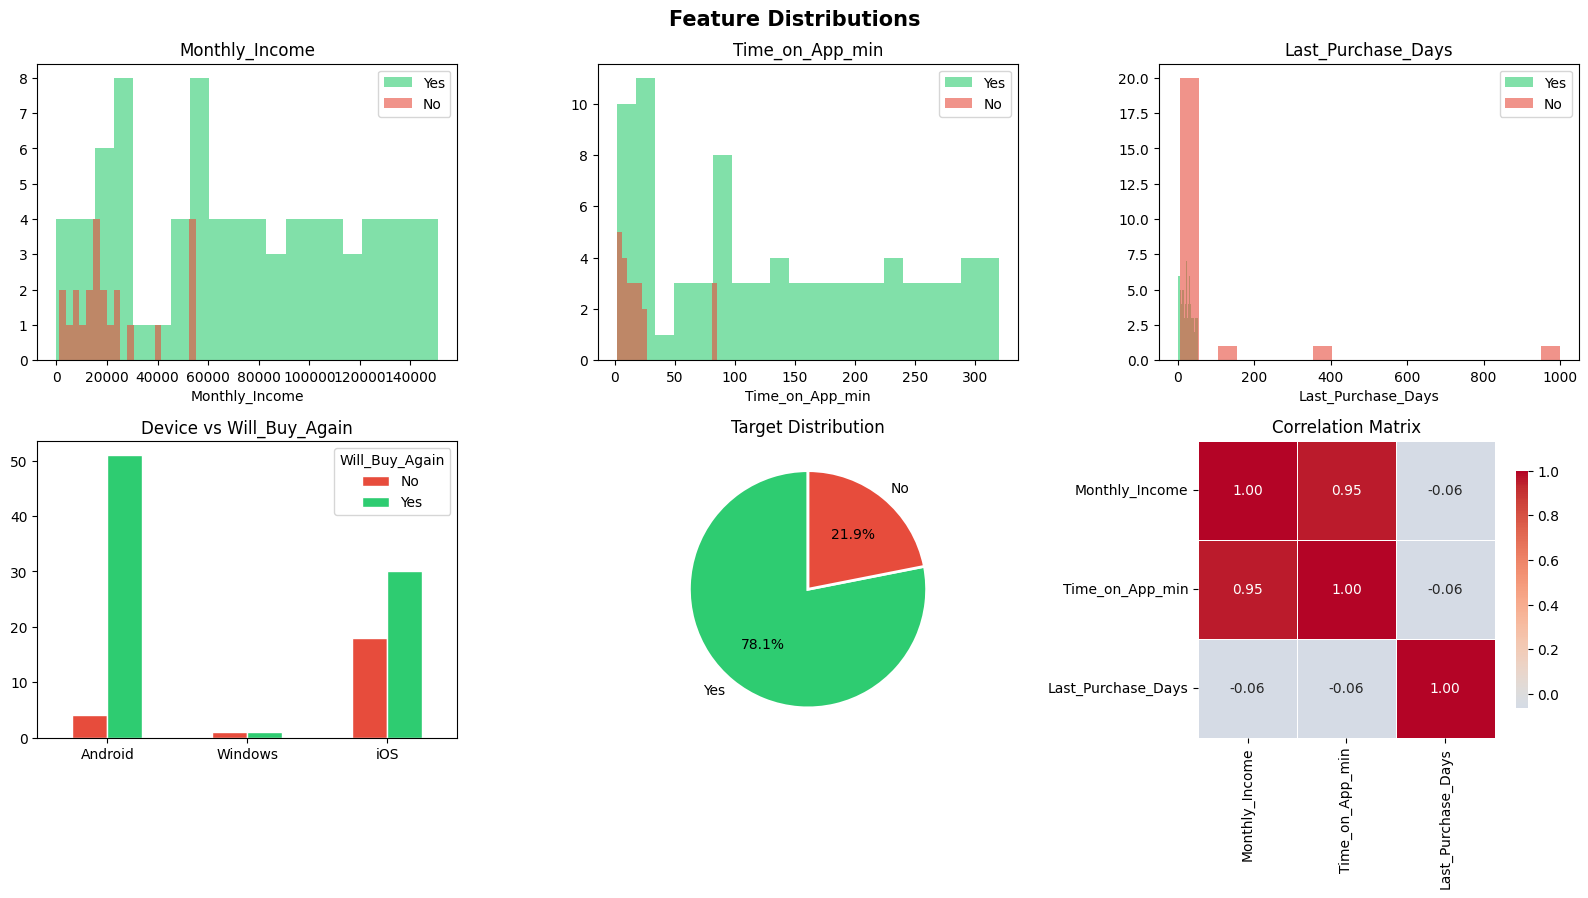

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Distributions', fontsize=15, fontweight='bold')

num_cols = ['Monthly_Income', 'Time_on_App_min', 'Last_Purchase_Days']
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, col in enumerate(num_cols):
    # Histogram by class
    for label, color in zip(['Yes', 'No'], ['#2ecc71', '#e74c3c']):
        axes[0, i].hist(df[df['Will_Buy_Again'] == label][col],
                        bins=20, alpha=0.6, label=label, color=color)
    axes[0, i].set_title(col)
    axes[0, i].legend()
    axes[0, i].set_xlabel(col)

# Device counts
device_counts = df.groupby(['Device', 'Will_Buy_Again']).size().unstack()
device_counts.plot(kind='bar', ax=axes[1, 0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1, 0].set_title('Device vs Will_Buy_Again')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=0)

# Target distribution
target_counts = df['Will_Buy_Again'].value_counts()
axes[1, 1].pie(target_counts, labels=target_counts.index,
               autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
               startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1, 1].set_title('Target Distribution')

# Correlation heatmap
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 2], center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [9]:
# ── One-Hot Encode Device ─────────────────────────────────────────────
df_encoded = pd.get_dummies(df.drop('Cust_ID', axis=1), columns=['Device'], drop_first=False)

# ── Encode Target ─────────────────────────────────────────────────────
df_encoded['Will_Buy_Again'] = (df_encoded['Will_Buy_Again'] == 'Yes').astype(int)

print('Features after encoding:')
print(df_encoded.columns.tolist())
print('\nShape:', df_encoded.shape)
df_encoded.head()

Features after encoding:
['Monthly_Income', 'Time_on_App_min', 'Last_Purchase_Days', 'Will_Buy_Again', 'Device_Android', 'Device_Windows', 'Device_iOS']

Shape: (105, 7)


,Monthly_Income,Time_on_App_min,Last_Purchase_Days,Will_Buy_Again,Device_Android,Device_Windows,Device_iOS
0,25000.0,15.2,3.0,1,True,False,False
1,30000.0,85.0,120.0,0,False,False,True
2,15000.0,5.0,23.0,0,False,True,False
3,55000.0,300.5,1.0,1,False,False,True
4,55000.0,10.0,45.0,0,True,False,False


In [10]:
# ── Train / Test Split ────────────────────────────────────────────────
feature_cols = [c for c in df_encoded.columns if c != 'Will_Buy_Again']
X = df_encoded[feature_cols].values
y = df_encoded['Will_Buy_Again'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Standard Scaling ─────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train_sc.shape[0]}  |  Test size: {X_test_sc.shape[0]}')
print(f'Features  : {X_train_sc.shape[1]}')
print(f'Class balance (train) — 0:{(y_train==0).sum()}  1:{(y_train==1).sum()}')

Train size: 84  |  Test size: 21
Features  : 6
Class balance (train) — 0:18  1:66


In [11]:
def build_model(input_dim, dropout_rate=0.3, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1
        layers.Dense(64, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),

        # Hidden layer 2
        layers.Dense(32, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),

        # Hidden layer 3
        layers.Dense(16, activation='relu'),

        # Output
        layers.Dense(1, activation='sigmoid')
    ], name='CustomerPurchaseNN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

model = build_model(input_dim=X_train_sc.shape[1])
model.summary()

Model: "CustomerPurchaseNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 192 (768.00 B)

In [12]:
# ── Callbacks ─────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor='val_auc', patience=15, restore_best_weights=True, mode='max'
)
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1
)

# ── Train ─────────────────────────────────────────────────────────────
history = model.fit(
    X_train_sc, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)
print('\nTraining complete!')

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.2254 - auc: 0.2762 - loss: 0.8548 - precision: 0.5263 - recall: 0.1786 - val_accuracy: 0.4615 - val_auc: 0.6500 - val_loss: 0.6873 - val_precision: 0.8000 - val_recall: 0.4000 - learning_rate: 0.0010
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3944 - auc: 0.5119 - loss: 0.7824 - precision: 0.7826 - recall: 0.3214 - val_accuracy: 0.5385 - val_auc: 0.6333 - val_loss: 0.6386 - val_precision: 0.8333 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5211 - auc: 0.6220 - loss: 0.7229 - precision: 0.9231 - recall: 0.4286 - val_accuracy: 0.5385 - val_auc: 0.6667 - val_loss: 0.6041 - val_precision: 0.7500 - val_recall: 0.6000 - learning_rate: 0.0010
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5493 - auc: 0.6435 - loss: 0.6902 - precision: 0.9286 - recall: 0.4643 - val_accuracy: 0.6154 - val_auc: 0.6500 - val_loss: 0.5758 - val_precisi

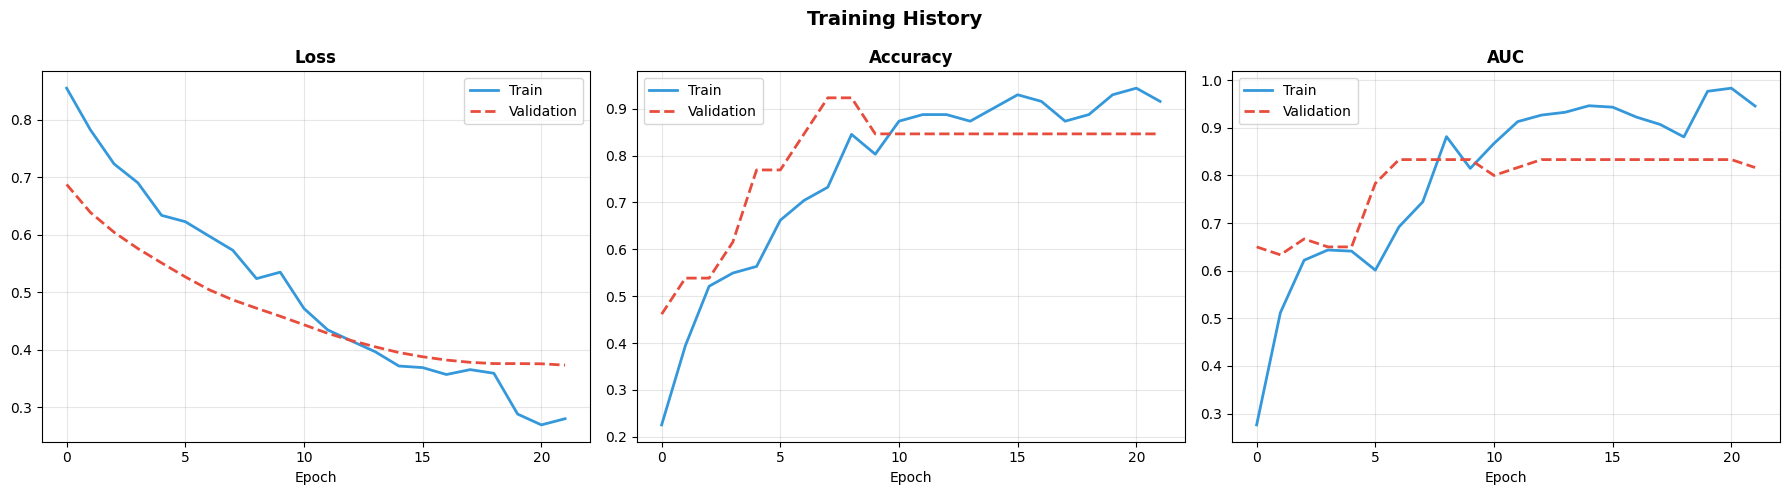

In [13]:
# ── Training Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

metrics_to_plot = [('loss', 'Loss'), ('accuracy', 'Accuracy'), ('auc', 'AUC')]

for ax, (metric, title) in zip(axes, metrics_to_plot):
    ax.plot(history.history[metric], label='Train', linewidth=2, color='#3498db')
    ax.plot(history.history[f'val_{metric}'], label='Validation', linewidth=2,
            color='#e74c3c', linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ── Test Set Evaluation ───────────────────────────────────────────────
y_prob = model.predict(X_test_sc).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print('='*50)
print('TEST SET RESULTS')
print('='*50)

results = model.evaluate(X_test_sc, y_test, verbose=0)
metric_names = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']
for name, val in zip(metric_names, results):
    print(f'  {name:12s}: {val:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Will NOT Buy', 'Will Buy']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
TEST SET RESULTS
  Loss        : 1.2934
  Accuracy    : 0.7619
  AUC         : 0.4625
  Precision   : 0.7619
  Recall      : 1.0000

Classification Report:
              precision    recall  f1-score   support

Will NOT Buy       0.00      0.00      0.00         5
    Will Buy       0.76      1.00      0.86        16

    accuracy                           0.76        21
   macro avg       0.38      0.50      0.43        21
weighted avg       0.58      0.76      0.66        21



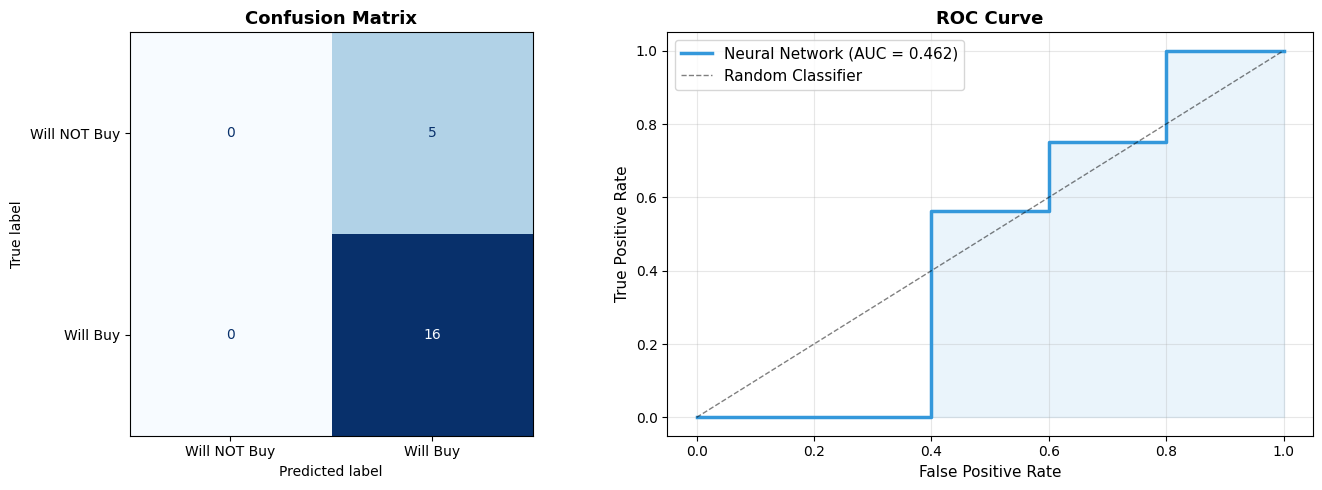

In [15]:
# ── Confusion Matrix + ROC Curve ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Will NOT Buy', 'Will Buy'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2.5,
             label=f'Neural Network (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

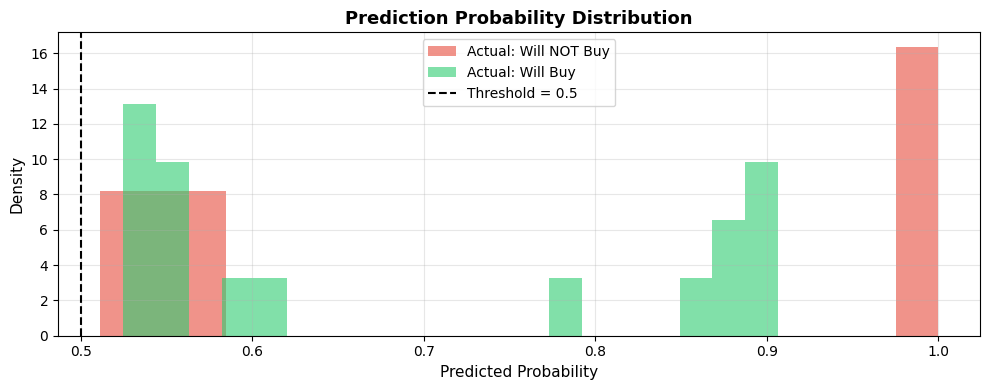

In [16]:
# ── Probability Distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(y_prob[y_test == 0], bins=20, alpha=0.6, color='#e74c3c',
        label='Actual: Will NOT Buy', density=True)
ax.hist(y_prob[y_test == 1], bins=20, alpha=0.6, color='#2ecc71',
        label='Actual: Will Buy', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax.set_xlabel('Predicted Probability', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Prediction Probability Distribution', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# สร้าง DataFrame ของ feature columns (ต้องตรงกับ training)
print('Feature columns used during training:')
print(feature_cols)

# ตัวอย่างลูกค้าใหม่ 3 คน
new_customers = pd.DataFrame({
    'Monthly_Income':    [35000, 8000, 70000],
    'Time_on_App_min':   [45.0,  5.0,  120.0],
    'Last_Purchase_Days':[7,     90,   3],
    'Device_Android':    [1, 0, 0],
    'Device_iOS':        [0, 1, 1],
    'Device_Windows':    [0, 0, 0],
})

# เติม columns ที่อาจขาด (ถ้า get_dummies สร้างไว้)
for col in feature_cols:
    if col not in new_customers.columns:
        new_customers[col] = 0
new_customers = new_customers[feature_cols]

new_scaled = scaler.transform(new_customers)
new_probs  = model.predict(new_scaled).flatten()
new_preds  = ['Will Buy 🟢' if p >= 0.5 else 'Will NOT Buy 🔴' for p in new_probs]

result_df = new_customers.copy()
result_df['Predicted_Prob'] = new_probs.round(4)
result_df['Prediction']     = new_preds

print('\n🔮 New Customer Predictions:')
result_df

Feature columns used during training:
['Monthly_Income', 'Time_on_App_min', 'Last_Purchase_Days', 'Device_Android', 'Device_Windows', 'Device_iOS']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

🔮 New Customer Predictions:


,Monthly_Income,Time_on_App_min,Last_Purchase_Days,Device_Android,Device_Windows,Device_iOS,Predicted_Prob,Prediction
0,35000,45.0,7,1,0,0,0.5900,Will Buy 🟢
1,8000,5.0,90,0,0,1,0.6509,Will Buy 🟢
2,70000,120.0,3,0,0,1,0.8094,Will Buy 🟢


In [19]:
model.save('../models/customer_purchase_nn.keras')
print('✅ Model saved as customer_purchase_nn.keras')

✅ Model saved as customer_purchase_nn.keras
